In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [25]:
df = pd.read_csv('data/pre-thin-data.csv')
df.head()
df['status'] = df['pre_HT'].apply(lambda x: 'Alive' if pd.notnull(x) and x > 0 else 'Dead')

### Row-Thinning Strategy Ranking Methods

We are comparing the *k*-row thinning (k = 3, 4, 5) methods on two objectives:

- **Primary**: retaining the big trees — quantified by **Q4 retention ratio:**  
  $$
  r_{Q4} = \frac{\text{kept Q4}}{\text{pre Q4}}
  $$

- **Secondary**: removing small trees — quantified by **Q1 removal ratio:**  
  $$
  r_{Q1} = \frac{\text{removed Q1}}{\text{pre Q1}}
  $$


---


In [43]:

def k_row_thinning(df, k:int, start_row:int=1, row_col='Row', status_col='status'):

    assert k >= 2 and 1 <= start_row <= k
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    rows_to_thin = ((d[row_col] - start_row) % k == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

three_row_thinning = lambda df, start_row=1: k_row_thinning(df, 3, start_row)
four_row_thinning  = lambda df, start_row=1: k_row_thinning(df, 4, start_row)
five_row_thinning  = lambda df, start_row=1: k_row_thinning(df, 5, start_row)


def stand_analysis(df_thinned, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status'):
    alive   = df_thinned[df_thinned[status_col] == 'Alive'].copy()
    kept    = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    # volumes
    pre_total_vol     = float(alive[vol_col].sum())   if len(alive) else 0.0
    post_total_vol    = float(kept[vol_col].sum())    if len(kept)  else 0.0
    removed_total_vol = float(removed[vol_col].sum()) if len(removed) else 0.0

    # central tendencies
    pre_median  = float(alive[metric].median()) if len(alive) else np.nan
    pre_mean    = float(alive[metric].mean())   if len(alive) else np.nan
    post_median = float(kept[metric].median())  if len(kept)  else np.nan
    post_mean   = float(kept[metric].mean())    if len(kept)  else np.nan
    d_median    = (post_median - pre_median) if (not np.isnan(post_median) and not np.isnan(pre_median)) else np.nan
    d_mean      = (post_mean   - pre_mean)   if (not np.isnan(post_mean)   and not np.isnan(pre_mean))   else np.nan

    # quartiles
    q1 = alive[metric].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric].quantile(0.75) if len(alive) else np.nan

    # counts by quartile
    L_pre  = int((alive [metric] <= q1).sum()) if len(alive) else 0  # Q1
    H_pre  = int((alive [metric] >= q3).sum()) if len(alive) else 0  # Q4
    L_post = int((kept  [metric] <= q1).sum()) if len(kept)  else 0
    H_post = int((kept  [metric] >= q3).sum()) if len(kept)  else 0

    # removed by quartile
    L_cut = L_pre - L_post
    H_cut = H_pre - H_post

    # volume by Q4 removed
    removed_q4_vol = float(removed.loc[removed[metric] >= q3, vol_col].sum()) if len(removed) else 0.0
    pct_removed_vol_from_q4 = (100 * removed_q4_vol / removed_total_vol) if removed_total_vol > 0 else np.nan

    # key ratios
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan              # Q4 retention ratio
    r_q1 = (L_cut / L_pre) if L_pre > 0 else np.nan               # Q1 removal ratio

    return {
        
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(len(kept)),
        'Trees removed': int(len(removed)),

        
        'Q1 cut (count)': int(L_cut),
        'Q4 cut (count)': int(H_cut),
        'Q4 remaining (count)': int(H_post),
        'Removed volume from Q4': round(removed_q4_vol, 2),
        '% of removed volume from Q4': round(pct_removed_vol_from_q4, 2) if not np.isnan(pct_removed_vol_from_q4) else np.nan,

        # ratios
        'Q1 removal ratio (removed/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,

        'Q1 pre (count)': int(L_pre),
        'Q4 pre (count)': int(H_pre),

        # DBH/volume stats
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median, 2) if not np.isnan(pre_median) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2)     if not np.isnan(pre_mean)   else np.nan,
        'Post-thinning median DBH': round(post_median, 2) if not np.isnan(post_median) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2)     if not np.isnan(post_mean)   else np.nan,
        'Change in median DBH': round(d_median, 2) if not np.isnan(d_median) else np.nan,
        'Change in mean DBH':   round(d_mean, 2)   if not np.isnan(d_mean)   else np.nan,
    }

def build_comp_for_k(df, k:int, metric='pre_DBH', vol_col='pre_stem_vol',
                     row_col='Row', status_col='status'):
    rows = []
    for s in range(1, k+1):
        d = k_row_thinning(df, k, s, row_col=row_col, status_col=status_col)
        a = stand_analysis(d, metric=metric, vol_col=vol_col, status_col=status_col)
        a['Strategy']  = f'{k}-row start={s}'
        a['k']         = k
        a['start_row'] = s
        rows.append(a)
    comp = pd.DataFrame(rows)
    for c in ('Q4 retention ratio (post/pre)', 'Q1 removal ratio (removed/pre)'):
        if c in comp.columns: comp[c] = pd.to_numeric(comp[c], errors='coerce')
    return comp

from IPython.display import display

def style_comp_table(comp_ranked: pd.DataFrame, title=None):
    show = [
        'Strategy',
        # 'Composite', 
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4','Removed volume from Q4',
        'Volume removed','Post-thinning total volume',
        'start_row'
    ]
    cols = [c for c in show if c in comp_ranked.columns]
    tbl = comp_ranked[cols].copy()

    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    ratio_cols = ['Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)']
    money_cols = ['Removed volume from Q4','Volume removed','Post-thinning total volume']

    sty = (tbl.reset_index(drop=True).style
           .format({c:'{:,.0f}' for c in count_cols if c in tbl})
           .format({c:'{:.2f}%' for c in pct_cols   if c in tbl})
           .format({c:'{:.3f}'  for c in ratio_cols if c in tbl})
           .format({c:'{:,.2f}' for c in money_cols if c in tbl})
           .format({'Composite':'{:,.6f}'})
           .set_caption(title or 'Strategy comparison')
           .hide(axis='index'))
    return sty

def plot_q4_q1_scatter(comp, title='', delta=None):
    """Scatter of Q4 retention (x) vs Q1 removal (y); optional vertical tie-band of width delta."""
    q4 = comp['Q4 retention ratio (post/pre)'].astype(float)
    q1 = comp['Q1 removal ratio (removed/pre)'].astype(float)
    labels = comp['start_row'].astype(int)

    plt.figure(figsize=(6.5,4.5))
    plt.scatter(q4, q1, s=60, edgecolors='k', linewidths=0.5)
    for x,y,l in zip(q4,q1,labels):
        plt.text(x, y, str(l), ha='center', va='bottom', fontsize=9)
    if delta is not None:
        x_best = float(q4.max())
        plt.axvspan(x_best-delta, x_best, alpha=0.3, label=f'Q4 tie-band (δ={delta:.4f})')
        plt.axvline(x_best, linestyle='--', alpha=0.4)
    plt.xlabel('Q4 retention ratio (post/pre)')
    plt.ylabel('Q1 removal ratio (removed/pre)')
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Strategy 1 — Weighted Sum

**Idea** -> Score = w₁·(Q4 retention) + w₂·(Q1 removal), with w₁ + w₂ = 1.  


**Pros**
- Simple to implement.

**Cons**
- Violates the ordered(lexicographic) intent, q1 removal can compensate for the difference in q4 retention, that can select strategies that keep fewer big trees.
- Weights are arbitrary and dataset-dependent.




Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
5-row start=5,18.500000,18.780000,2459,558,125,0.159000,655,159,0.805000,41.540000,3209.870000,7726.530000,33419.780000,5
5-row start=2,20.680000,20.580000,2393,624,166,0.211000,654,160,0.803000,38.940000,3296.460000,8466.460000,32679.840000,2
5-row start=1,19.690000,19.810000,2423,594,156,0.198000,651,163,0.800000,40.730000,3319.440000,8149.610000,32996.690000,1
5-row start=4,20.780000,20.450000,2390,627,184,0.234000,650,164,0.799000,39.680000,3339.390000,8415.520000,32730.790000,4
5-row start=3,20.350000,20.390000,2403,614,157,0.199000,646,168,0.794000,40.510000,3398.220000,8388.190000,32758.120000,3


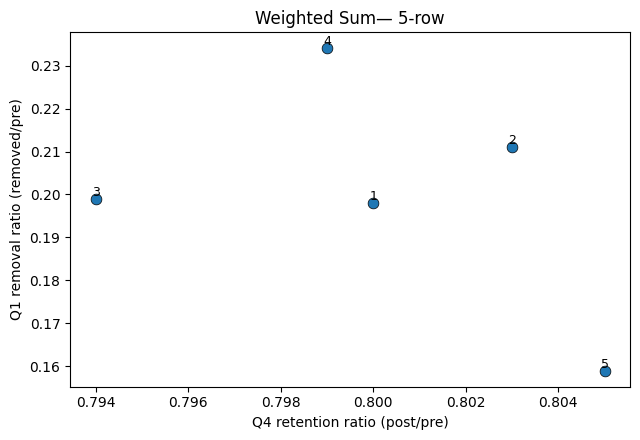

In [46]:
def rank_weighted_sum(comp, w_q4=0.8, w_q1=0.2):
    df = comp.copy()
    q4 = df['Q4 retention ratio (post/pre)'].astype(float)
    q1 = df['Q1 removal ratio (removed/pre)'].astype(float)

    
    q4n = (q4 - q4.min())/(q4.max()-q4.min()+1e-12)
    q1n = (q1 - q1.min())/(q1.max()-q1.min()+1e-12)

    df['Composite'] = w_q4*q4n + w_q1*q1n
    return df.sort_values('Composite', ascending=False).reset_index(drop=True)

comp5 = build_comp_for_k(df, k=5)
ranked_wsum_5 = rank_weighted_sum(comp5, w_q4=0.85, w_q1=0.15)
display(style_comp_table(ranked_wsum_5, 'Weighted Sum (wQ4=0.85, wQ1=0.15) — 5-row'))
plot_q4_q1_scatter(comp5, 'Weighted Sum— 5-row')


## Strategy 2 — Lexicographic with Fixed 2 percentage points Band

**Idea** -> Treat Q4 differences below **2 percentage points** as a tie; within
that band, pick the higher Q1 removal.

**Pros**
- Matches our *intent* better than weighted sum.

**Cons**
- Ignores scale: in very tight ranges (e.g., all Q4 within 0.6pp), a 2pp
  band is too large; in wide ranges it can be too strict.
- Doesn’t automatically adapt across different stands.



Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
5-row start=4,20.780000,20.450000,2390,627,184,0.234000,650,164,0.799000,39.680000,3339.390000,8415.520000,32730.790000,4
5-row start=2,20.680000,20.580000,2393,624,166,0.211000,654,160,0.803000,38.940000,3296.460000,8466.460000,32679.840000,2
5-row start=3,20.350000,20.390000,2403,614,157,0.199000,646,168,0.794000,40.510000,3398.220000,8388.190000,32758.120000,3
5-row start=1,19.690000,19.810000,2423,594,156,0.198000,651,163,0.800000,40.730000,3319.440000,8149.610000,32996.690000,1
5-row start=5,18.500000,18.780000,2459,558,125,0.159000,655,159,0.805000,41.540000,3209.870000,7726.530000,33419.780000,5


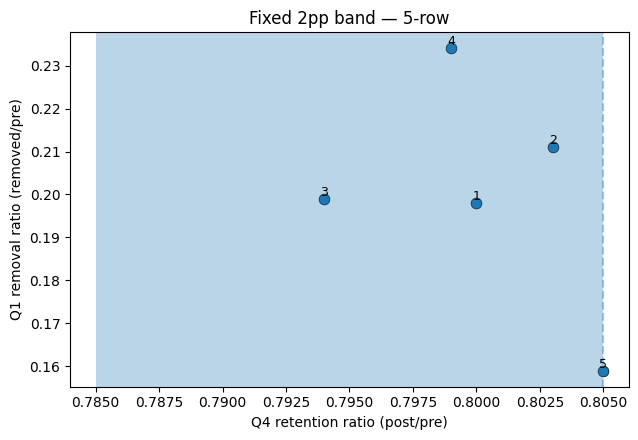

In [44]:
def lexi_fixed_band(comp,delta):
    df = comp.copy()
    q4 = df['Q4 retention ratio (post/pre)'].astype(float)
    q1 = df['Q1 removal ratio (removed/pre)'].astype(float)
    best = float(q4.max())

    df['_Q4_close'] = (best - q4) <= float(delta)
    df['_q1_if_close'] = np.where(df['_Q4_close'], q1, -np.inf)
    df['Composite'] = df['_Q4_close'].astype(float)*1e-6*q1 + q4

    df = (df.sort_values(by=['_Q4_close','_q1_if_close','Q4 retention ratio (post/pre)'],
                         ascending=[False, False, False])
            .drop(columns=['_Q4_close','_q1_if_close'])
            .reset_index(drop=True))
    df.attrs['delta'] = float(delta)
    return df

ranked_fix_5 = lexi_fixed_band(comp5, delta=0.02)  # 0.2pp as absolute band
display(style_comp_table(ranked_fix_5, 'Lexicographic (2pp band) — 5-row'))
plot_q4_q1_scatter(comp5, 'Fixed 2pp band — 5-row', delta=0.02)


## Strategy 3 — Lexicographic with Statistical Tie (lexi-sig)

**Idea.** Two strategies are “Q4-close” if their Q4 retention difference is
smaller than a **z·SE margin** for the difference of proportions. Within the
“close” set, Q1 is used to break ties.

**Pros**
- Adapts to sample size and variance (more Q4 trees makes the metric stricter).

**Cons**
- Requires choosing α and an SE variant which are dependent on the stand (pooled vs unpooled).
- In very large stands, it can be *too* strict; in tiny stands, *too* lenient.



Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
5-row start=4,20.780000,20.450000,2390,627,184,0.234000,650,164,0.799000,39.680000,3339.390000,8415.520000,32730.790000,4
5-row start=2,20.680000,20.580000,2393,624,166,0.211000,654,160,0.803000,38.940000,3296.460000,8466.460000,32679.840000,2
5-row start=3,20.350000,20.390000,2403,614,157,0.199000,646,168,0.794000,40.510000,3398.220000,8388.190000,32758.120000,3
5-row start=1,19.690000,19.810000,2423,594,156,0.198000,651,163,0.800000,40.730000,3319.440000,8149.610000,32996.690000,1
5-row start=5,18.500000,18.780000,2459,558,125,0.159000,655,159,0.805000,41.540000,3209.870000,7726.530000,33419.780000,5


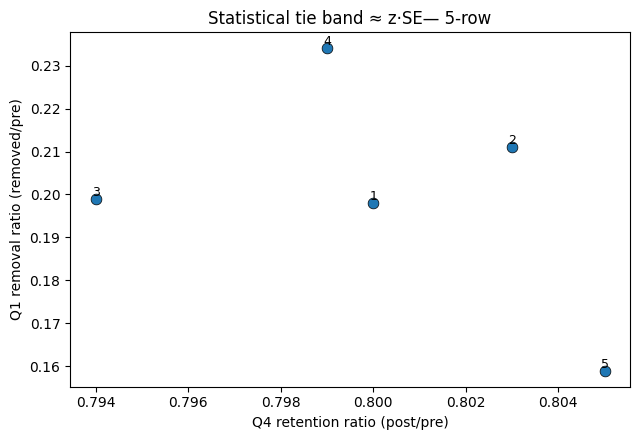

In [47]:
from math import sqrt

def z_from_alpha(alpha=0.05):
    table = {0.10:1.6448536269514722, 0.05:1.959963984540054, 0.02:2.3263478740408408, 0.01:2.5758293035489004}
    return table.get(alpha, 1.959963984540054)

def lexi_with_significance(comp, alpha=0.05, se_mode='unpooled'):
    df = comp.copy()
    need = {'Q4 retention ratio (post/pre)','Q4 pre (count)','Q1 removal ratio (removed/pre)'}
    if not need.issubset(df.columns): raise ValueError("Missing columns for lexi-sig")

    q4 = df['Q4 retention ratio (post/pre)'].astype(float)
    best_idx = q4.idxmax()
    p_b = float(df.loc[best_idx, 'Q4 retention ratio (post/pre)'])
    n_b = float(df.loc[best_idx, 'Q4 pre (count)'])

    z = z_from_alpha(alpha)
    def se_diff(p_b, n_b, p_i, n_i):
        if se_mode == 'unpooled':
            return sqrt((p_b*(1-p_b))/n_b + (p_i*(1-p_i))/n_i)
        elif se_mode == 'common':
            return sqrt((p_b*(1-p_b))/n_b + (p_b*(1-p_b))/n_i)
        else:  # pooled
            p_pool = ((p_b*n_b) + (p_i*n_i)) / (n_b + n_i)
            return sqrt(p_pool*(1-p_pool)*(1/n_b + 1/n_i))

    def is_close(row):
        p_i = float(row['Q4 retention ratio (post/pre)'])
        n_i = float(row['Q4 pre (count)'])
        se = se_diff(p_b, n_b, p_i, n_i)
        return (p_b - p_i) <= z*se

    df['_Q4_close'] = df.apply(is_close, axis=1)
    q1 = df['Q1 removal ratio (removed/pre)'].astype(float).fillna(-np.inf)
    df['_q1_if_close'] = np.where(df['_Q4_close'], q1, -np.inf)
    df['Composite'] = q4 + df['_Q4_close'].astype(float)*1e-6*q1.clip(lower=0)

    df = (df.sort_values(by=['_Q4_close','_q1_if_close','Q4 retention ratio (post/pre)'],
                         ascending=[False, False, False])
            .drop(columns=['_Q4_close','_q1_if_close'])
            .reset_index(drop=True))
    df.attrs['alpha'] = alpha
    return df

ranked_sig_5 = lexi_with_significance(comp5, alpha=0.05, se_mode='unpooled')
display(style_comp_table(ranked_sig_5, 'Lexicographic (statistical tie, α=0.05) — 5-row'))
plot_q4_q1_scatter(comp5, 'Statistical tie band ≈ z·SE— 5-row')


## Strategy 4 — TOPSIS (distance to an ideal solution)

**Idea**-> Normalize metrics, define the **ideal best** (max Q4, max Q1) and
**ideal worst** (min Q4, min Q1). Pick the strategy closest to the ideal best
and farthest from the worst.

**Pros**
- Supports more than two metrics.

**Cons**
- Still trades Q4 against Q1; may prefer a higher Q1 even when Q4 is meaningfully lower.
- Requires weights; can be sensitive to normalization in very tight ranges.



Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
5-row start=4,20.780000,20.450000,2390,627,184,0.234000,650,164,0.799000,39.680000,3339.390000,8415.520000,32730.790000,4
5-row start=2,20.680000,20.580000,2393,624,166,0.211000,654,160,0.803000,38.940000,3296.460000,8466.460000,32679.840000,2
5-row start=3,20.350000,20.390000,2403,614,157,0.199000,646,168,0.794000,40.510000,3398.220000,8388.190000,32758.120000,3
5-row start=1,19.690000,19.810000,2423,594,156,0.198000,651,163,0.800000,40.730000,3319.440000,8149.610000,32996.690000,1
5-row start=5,18.500000,18.780000,2459,558,125,0.159000,655,159,0.805000,41.540000,3209.870000,7726.530000,33419.780000,5


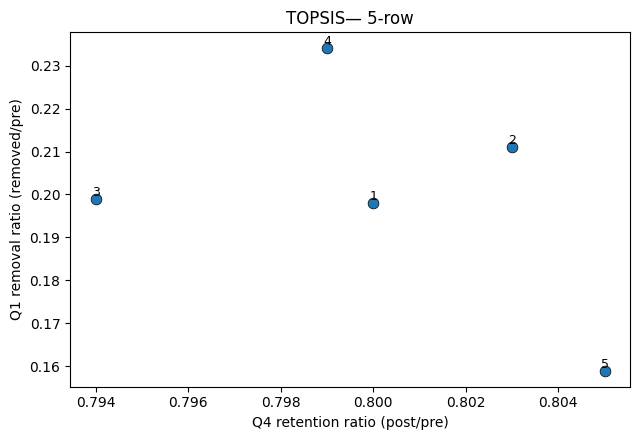

In [48]:
from math import sqrt

def topsis_rank(comp, weights=(0.7, 0.3)):
    df = comp.copy()
    q4 = df['Q4 retention ratio (post/pre)'].astype(float).values
    q1 = df['Q1 removal ratio (removed/pre)'].astype(float).values
    X = np.vstack([q4, q1]).T

    X_norm = X / (np.linalg.norm(X, axis=0, keepdims=True) + 1e-12)

    w = np.array(weights, dtype=float)
    w = w / (w.sum() + 1e-12)
    X_w = X_norm * w

    ideal_best  = np.max(X_w, axis=0)
    ideal_worst = np.min(X_w, axis=0)

    d_best  = np.linalg.norm(X_w - ideal_best , axis=1)
    d_worst = np.linalg.norm(X_w - ideal_worst, axis=1)

    score = d_worst / (d_best + d_worst + 1e-12)
    df['Composite'] = score
    return df.sort_values('Composite', ascending=False).reset_index(drop=True)


ranked_topsis_5 = topsis_rank(comp5, weights=(0.8, 0.2))
display(style_comp_table(ranked_topsis_5, 'TOPSIS (wQ4=0.8, wQ1=0.2) — 5-row'))
plot_q4_q1_scatter(comp5, 'TOPSIS— 5-row')


## Lexicographic with Adaptive Practical Tie-Band (Lexi-APB)

**Idea**-> Q4 is primary. Treat strategies as “Q4-close” when their Q4 retention
is within an **adaptive** band of the best:

$\delta = \mathrm{clip}\big(\lambda \cdot (\max r_{Q4} - \min r_{Q4}),\ \delta_{\min},\ \delta_{\max}\big)$

Within this band, choose the **higher Q1 removal**.

**Working in our case:**
- In 5-row case, start=2 is only ~0.2pp behind the highest Q4, but has
  ~5pp higher Q1 removal ⇒ **choose start=2**.
- In 4-row, start=2 is ~1pp behind but has ~5.5pp higher Q1 removal ⇒ **choose start=2**.
- In 3-row, Q4 gaps are large ⇒ **choose the top Q4** (start=3).

**Pros**
- Exactly enforces “Q4 first; Q1 only breaks near-ties”.
- **Stand-agnostic**: the band scales with the observed spread for that stand/k.




Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
5-row start=2,20.680000,20.580000,2393,624,166,0.211000,654,160,0.803000,38.940000,3296.460000,8466.460000,32679.840000,2
5-row start=1,19.690000,19.810000,2423,594,156,0.198000,651,163,0.800000,40.730000,3319.440000,8149.610000,32996.690000,1
5-row start=5,18.500000,18.780000,2459,558,125,0.159000,655,159,0.805000,41.540000,3209.870000,7726.530000,33419.780000,5
5-row start=4,20.780000,20.450000,2390,627,184,0.234000,650,164,0.799000,39.680000,3339.390000,8415.520000,32730.790000,4
5-row start=3,20.350000,20.390000,2403,614,157,0.199000,646,168,0.794000,40.510000,3398.220000,8388.190000,32758.120000,3


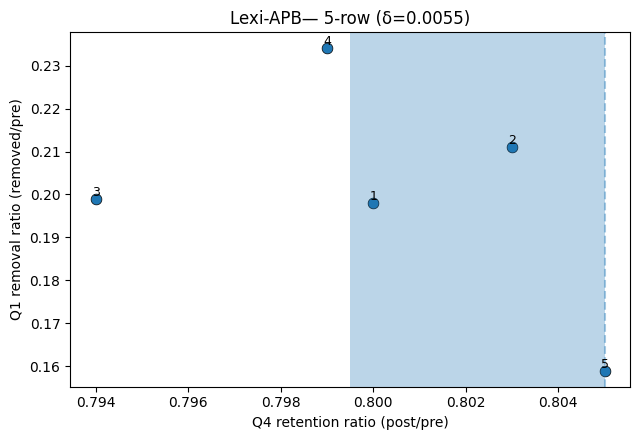

Winner (5-row): start_row = 2


Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
4-row start=2,25.390000,24.950000,2251,766,234,0.297000,613,201,0.753000,40.340000,4141.840000,10266.180000,30880.130000,2
4-row start=3,25.320000,25.140000,2253,764,191,0.242000,621,193,0.763000,37.970000,3927.180000,10342.170000,30804.130000,3
4-row start=1,24.560000,24.640000,2276,741,185,0.235000,606,208,0.744000,40.740000,4130.990000,10139.760000,31006.540000,1
4-row start=4,24.730000,25.270000,2271,746,178,0.226000,602,212,0.740000,41.960000,4363.370000,10398.190000,30748.110000,4


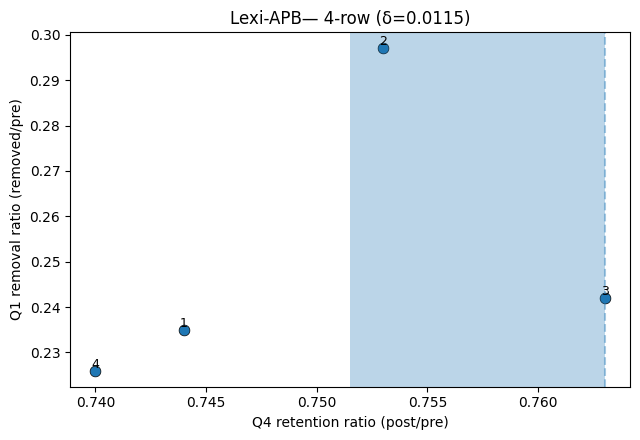

Winner (4-row): start_row = 2


Strategy,% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,start_row
3-row start=3,32.520000,32.540000,2036,981,254,0.322000,562,252,0.690000,38.560000,5162.020000,13388.630000,27757.680000,3
3-row start=2,33.080000,33.060000,2019,998,265,0.336000,539,275,0.662000,41.040000,5581.950000,13601.760000,27544.550000,2
3-row start=1,34.410000,34.400000,1979,1038,269,0.341000,527,287,0.647000,41.110000,5819.400000,14155.920000,26990.380000,1


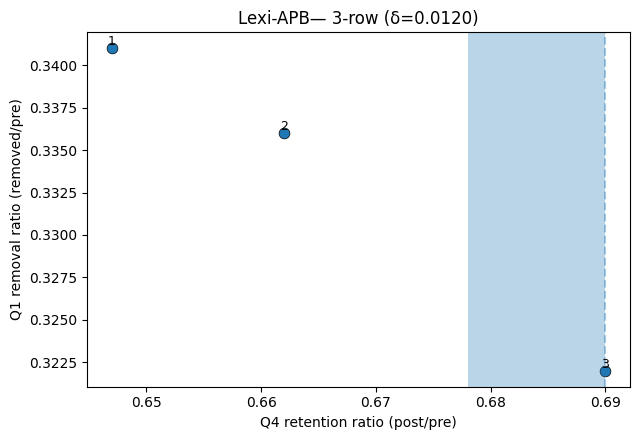

Winner (3-row): start_row = 3


In [49]:
def adaptive_practical_band(q4_series: pd.Series, lam:float=0.5, delta_min:float=0.002, delta_max:float=0.012):
    q4 = pd.to_numeric(q4_series, errors='coerce')
    rng = float(q4.max() - q4.min()) if len(q4.dropna()) else 0.0
    return float(np.clip(lam * rng, delta_min, delta_max))

def lexi_with_apb(comp: pd.DataFrame, lam:float=0.5, delta_min:float=0.002, delta_max:float=0.012, delta_override:float=None):
    df = comp.copy()
    need = {'Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)'}
    if not need.issubset(df.columns): raise ValueError("Missing columns for lexi-APB")


    q4 = df['Q4 retention ratio (post/pre)'].astype(float)
    delta = float(delta_override) if (delta_override is not None) else adaptive_practical_band(q4, lam, delta_min, delta_max)
    best_q4 = float(q4.max())

    df['_Q4_close'] = (best_q4 - q4) <= delta
    q1 = df['Q1 removal ratio (removed/pre)'].astype(float).fillna(-np.inf)


    df['_q1_if_close'] = np.where(df['_Q4_close'], q1, -np.inf)
    df['Composite'] = q4 + df['_Q4_close'].astype(float)*1e-6*q1.clip(lower=0)  # just for display

    df = (df.sort_values(by=['_Q4_close','_q1_if_close','Q4 retention ratio (post/pre)'],
                         ascending=[False, False, False])
            .drop(columns=['_Q4_close','_q1_if_close'])
            .reset_index(drop=True))
    df.attrs['apb_delta'] = delta
    return df


ranked_apb_5 = lexi_with_apb(comp5, lam=0.5, delta_min=0.002, delta_max=0.012)
display(style_comp_table(ranked_apb_5.rename(columns={'Composite':'Composite'}), 
                         f'Lexi-APB — 5-row (δ={ranked_apb_5.attrs["apb_delta"]:.4f})'))
plot_q4_q1_scatter(comp5, f'Lexi-APB— 5-row (δ={ranked_apb_5.attrs["apb_delta"]:.4f})',
                   delta=ranked_apb_5.attrs['apb_delta'])
print('Winner (5-row): start_row =', int(ranked_apb_5.iloc[0]['start_row']))


comp4 = build_comp_for_k(df, k=4)
ranked_apb_4 = lexi_with_apb(comp4, lam=0.5, delta_min=0.002, delta_max=0.012)
display(style_comp_table(ranked_apb_4, f'Lexi-APB — 4-row (δ={ranked_apb_4.attrs["apb_delta"]:.4f})'))
plot_q4_q1_scatter(comp4, f'Lexi-APB— 4-row (δ={ranked_apb_4.attrs["apb_delta"]:.4f})',
                   delta=ranked_apb_4.attrs['apb_delta'])
print('Winner (4-row): start_row =', int(ranked_apb_4.iloc[0]['start_row']))

comp3 = build_comp_for_k(df, k=3)
ranked_apb_3 = lexi_with_apb(comp3, lam=0.5, delta_min=0.002, delta_max=0.012)
display(style_comp_table(ranked_apb_3, f'Lexi-APB — 3-row (δ={ranked_apb_3.attrs["apb_delta"]:.4f})'))
plot_q4_q1_scatter(comp3, f'Lexi-APB— 3-row (δ={ranked_apb_3.attrs["apb_delta"]:.4f})',
                   delta=ranked_apb_3.attrs['apb_delta'])
print('Winner (3-row): start_row =', int(ranked_apb_3.iloc[0]['start_row']))


## Summary
- **Weighted sum**: simple but trades Q4 vs Q1 even when Q4 gaps are meaningful.
- **Lexicographic (fixed 2pp)**: interpretable, but does not adapt to each stand’s Q4 spread.
- **Lexicographic (statistical tie)**: principled, but can be overly strict/lenient depending on n.
- **TOPSIS**: multi-criteria distance to ideal; again trades Q4 for Q1 and needs weights.

**Lexi-APB**:
- Enforces **Q4 as primary**, uses **Q1 only inside a small, adaptive near-tie band**.
- The band scales with the observed Q4 spread for the stand and k, with sensible caps.
- Works consistently across different stands.
